# ECDF rare-event threshold analysis

Uses `mfpt_all_thresholds-new-ref.pkl` to find thresholds that best fit an exponential rare-event model.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats
import seaborn as sns
from statsmodels.stats.diagnostic import lilliefors

from common.consts import proteins
from paper.style_utils import set_paper_style
from common.utils import estimateMFPT
set_paper_style()

sns.set_theme(style="whitegrid")

plt.rcParams['figure.dpi'] = 300

k = 10


In [2]:
data_dir = repo_root / 'data'
mfpt_raw_pkl = data_dir / 'mfpt-pace=25000-new-ref.pkl'

all_mfpt = pd.read_pickle(mfpt_raw_pkl)
thresholds = sorted({float(k) for v in all_mfpt.values() for k in v.keys()})

names = list(proteins)


In [3]:
bad_names = [
    name for name in names
    if name != 'WT' and any(len(all_mfpt[name][thr]) < 50 for thr in thresholds)
]
names = [name for name in names if name not in bad_names]

for name in bad_names:
    for thr in thresholds:
        
        if len(all_mfpt[name][thr]) < 50:
            print(name, name, thr, len(all_mfpt[name][thr]))


In [4]:
def fit_exp_ecdf_stats(samples):
    x = np.array(samples, float)

    x.sort()
    n = x.size
    def F(t, tau):
        return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, 'expon', args=(0, tau))
    return float(tau), float(D), float(p)


def lilliefors_exp_stats(samples):
    x = np.array(samples, float)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return np.nan, np.nan
    D, p = lilliefors(x, dist='exp')
    return float(D), float(p)


def stats_for_threshold(all_mfpt, names, thr):
    rows = []
    for name in names:
        samples = np.array(all_mfpt[name][thr], float)
        samples = samples[np.isfinite(samples)]
        samples.sort()
        _, k_dyn = estimateMFPT(samples, k)
        s = samples[:k_dyn]

        tau, ks_D, ks_p = fit_exp_ecdf_stats(s)
        lillie_D, lillie_p = lilliefors_exp_stats(s)
        rows.append({
            'name': name,
            'n': int(s.size),
            'tau': tau,
            'ks_D': ks_D,
            'ks_p': ks_p,
            'lillie_D': lillie_D,
            'lillie_p': lillie_p,
        })
    return pd.DataFrame(rows).set_index('name')


In [5]:
summary_rows = []
per_threshold = {}

for thr in thresholds:
    df = stats_for_threshold(all_mfpt, names, thr)
    per_threshold[thr] = df
    summary_rows.append({
        'threshold': float(thr),
        'median_ks_D': df['ks_D'].median(),
        'median_ks_p': df['ks_p'].median(),
        'median_lillie_D': df['lillie_D'].median(),
        'median_lillie_p': df['lillie_p'].median(),
        'frac_ks_p_gt_0_2': (df['ks_p'] > 0.2).mean(),
        'frac_lillie_p_gt_0_05': (df['lillie_p'] > 0.05).mean(),
        'frac_both_pass': ((df['ks_p'] > 0.2) & (df['lillie_p'] > 0.05)).mean(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('threshold')
summary_df


,threshold,median_ks_D,median_ks_p,median_lillie_D,median_lillie_p,frac_ks_p_gt_0_2,frac_lillie_p_gt_0_05,frac_both_pass
0,0.28,0.165106,0.363065,0.190180,0.079922,0.763158,0.578947,0.578947
1,0.30,0.164280,0.399475,0.186023,0.105779,0.763158,0.631579,0.605263
2,0.32,0.174575,0.394242,0.191656,0.099468,0.789474,0.710526,0.657895
3,0.34,0.163872,0.418995,0.187450,0.109388,0.894737,0.736842,0.710526
4,0.36,0.161168,0.563096,0.184096,0.195068,0.921053,0.842105,0.815789
5,0.38,0.174920,0.518244,0.198661,0.178337,0.973684,0.894737,0.894737
6,0.40,0.171722,0.540560,0.205765,0.181737,0.894737,0.789474,0.789474
7,0.42,0.172703,0.503632,0.192887,0.177712,0.921053,0.842105,0.842105
8,0.44,0.168077,0.439877,0.192633,0.097734,0.894737,0.763158,0.763158
9,0.46,0.170179,0.382187,0.189553,0.100828,0.842105,0.736842,0.710526


In [6]:
# import seaborn as sns
# import pandas as pd

# p = []
# d = []
# for thr in thresholds:
#     df = stats_for_threshold(all_mfpt, names, thr)
#     p.append(df.loc['WT', 'median_ks_p'])
#     d.append(df.loc['WT', 'median_lillie_p'])

# plot_df = pd.DataFrame({
#     'threshold': thresholds,
#     'p': p,
#     'd': d
# })

# sns.lineplot(
#     data=plot_df,
#     x='threshold',
#     y='p',
#     marker='o'
# )

# plt.show()

# sns.lineplot(
#     data=plot_df,
#     x='threshold',
#     y='d',
#     marker='o'
# )

# plt.show()


In [7]:
best_by_ks_D = summary_df.loc[summary_df['median_ks_D'].idxmin()]
best_by_ks_p = summary_df.loc[summary_df['median_ks_p'].idxmax()]
best_by_lillie_p = summary_df.loc[summary_df['median_lillie_p'].idxmax()]
best_by_both = summary_df.loc[summary_df['frac_both_pass'].idxmax()]

print(
    f"Best by median KS D: thr={best_by_ks_D['threshold']:.3f}, D={best_by_ks_D['median_ks_D']:.3g}, "
    f"p_med={best_by_ks_D['median_ks_p']:.3g}"
)
print(
    f"Best by median KS p: thr={best_by_ks_p['threshold']:.3f}, p_med={best_by_ks_p['median_ks_p']:.3g}, "
    f"D_med={best_by_ks_p['median_ks_D']:.3g}"
)
print(
    f"Best by median Lilliefors p: thr={best_by_lillie_p['threshold']:.3f}, p_med={best_by_lillie_p['median_lillie_p']:.3g}, "
    f"D_med={best_by_lillie_p['median_lillie_D']:.3g}"
)
print(
    f"Best by frac both pass: thr={best_by_both['threshold']:.3f}, frac={best_by_both['frac_both_pass']:.3g}"
)


Best by median KS D: thr=0.360, D=0.161, p_med=0.563
Best by median KS p: thr=0.360, p_med=0.563, D_med=0.161
Best by median Lilliefors p: thr=0.360, p_med=0.195, D_med=0.184
Best by frac both pass: thr=0.380, frac=0.895


Median Lilliefors p vs threshold


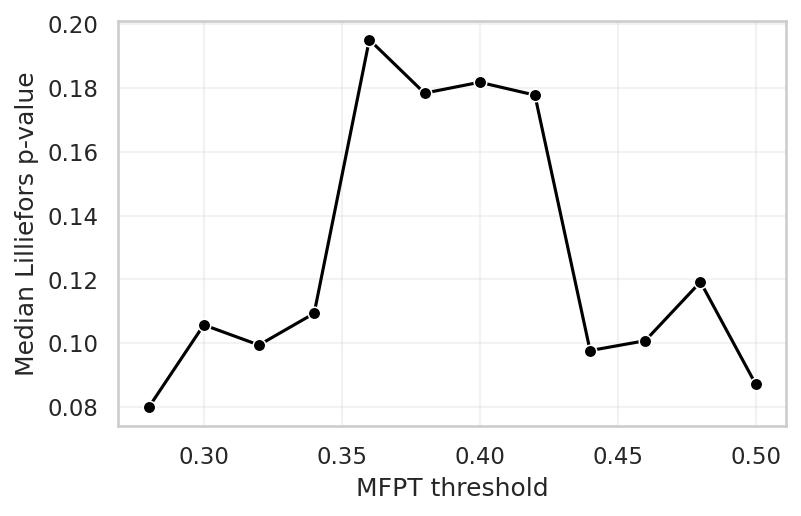

Fraction KS p > 0.2 & Lilliefors p > 0.05


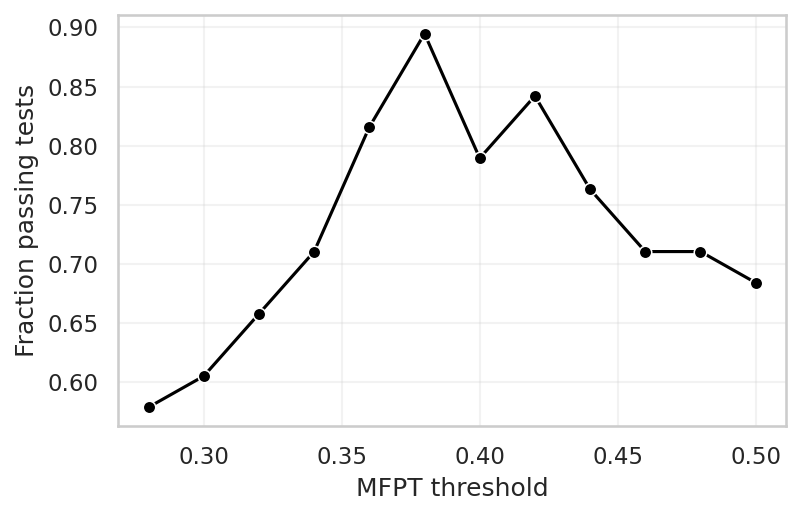

In [ ]:
# Median Lilliefors p vs threshold (separate)
print('Median Lilliefors p vs threshold')
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=200)
sns.lineplot(data=summary_df, x='threshold', y='median_lillie_p', marker='o', ax=ax, color='black')
ax.set_xlabel('MFPT threshold')
ax.set_ylabel('Median Lilliefors p-value')
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

# Fraction passing both tests (separate)
print('Fraction KS p > 0.2 & Lilliefors p > 0.05')
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=200)
sns.lineplot(data=summary_df, x='threshold', y='frac_both_pass', marker='o', ax=ax, color='black')
ax.set_xlabel('MFPT threshold')
ax.set_ylabel('Fraction passing tests')
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


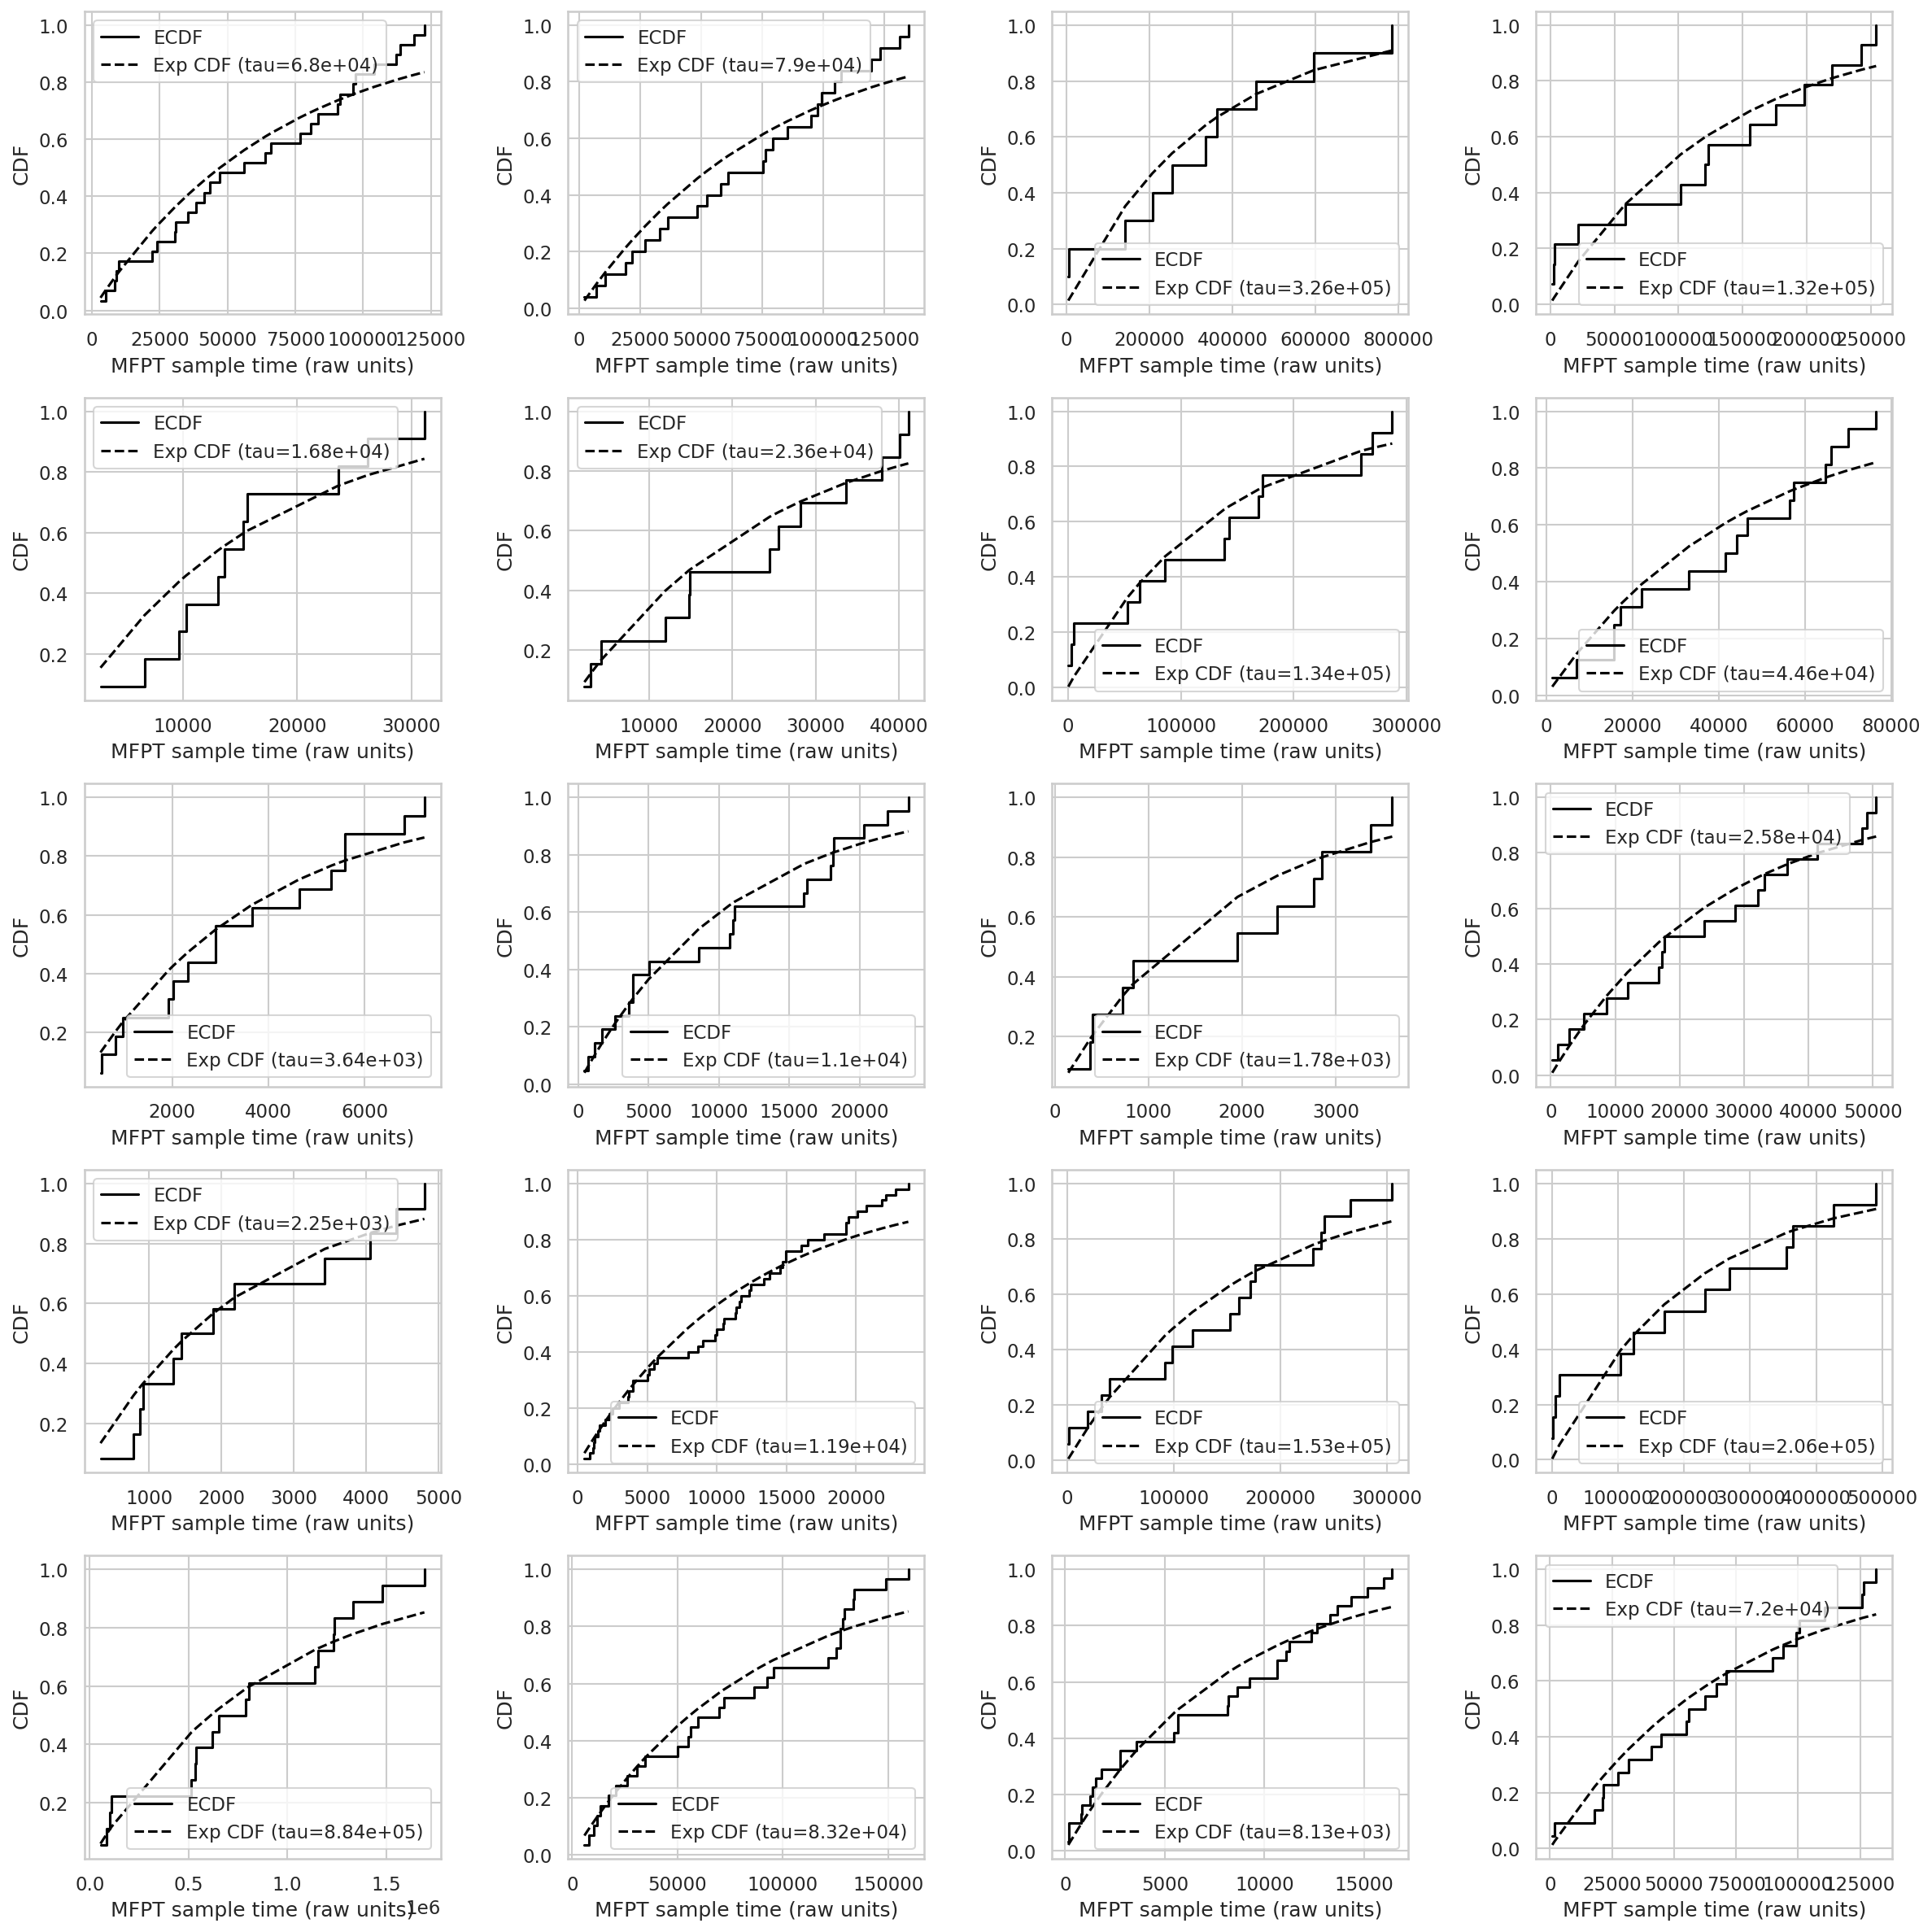

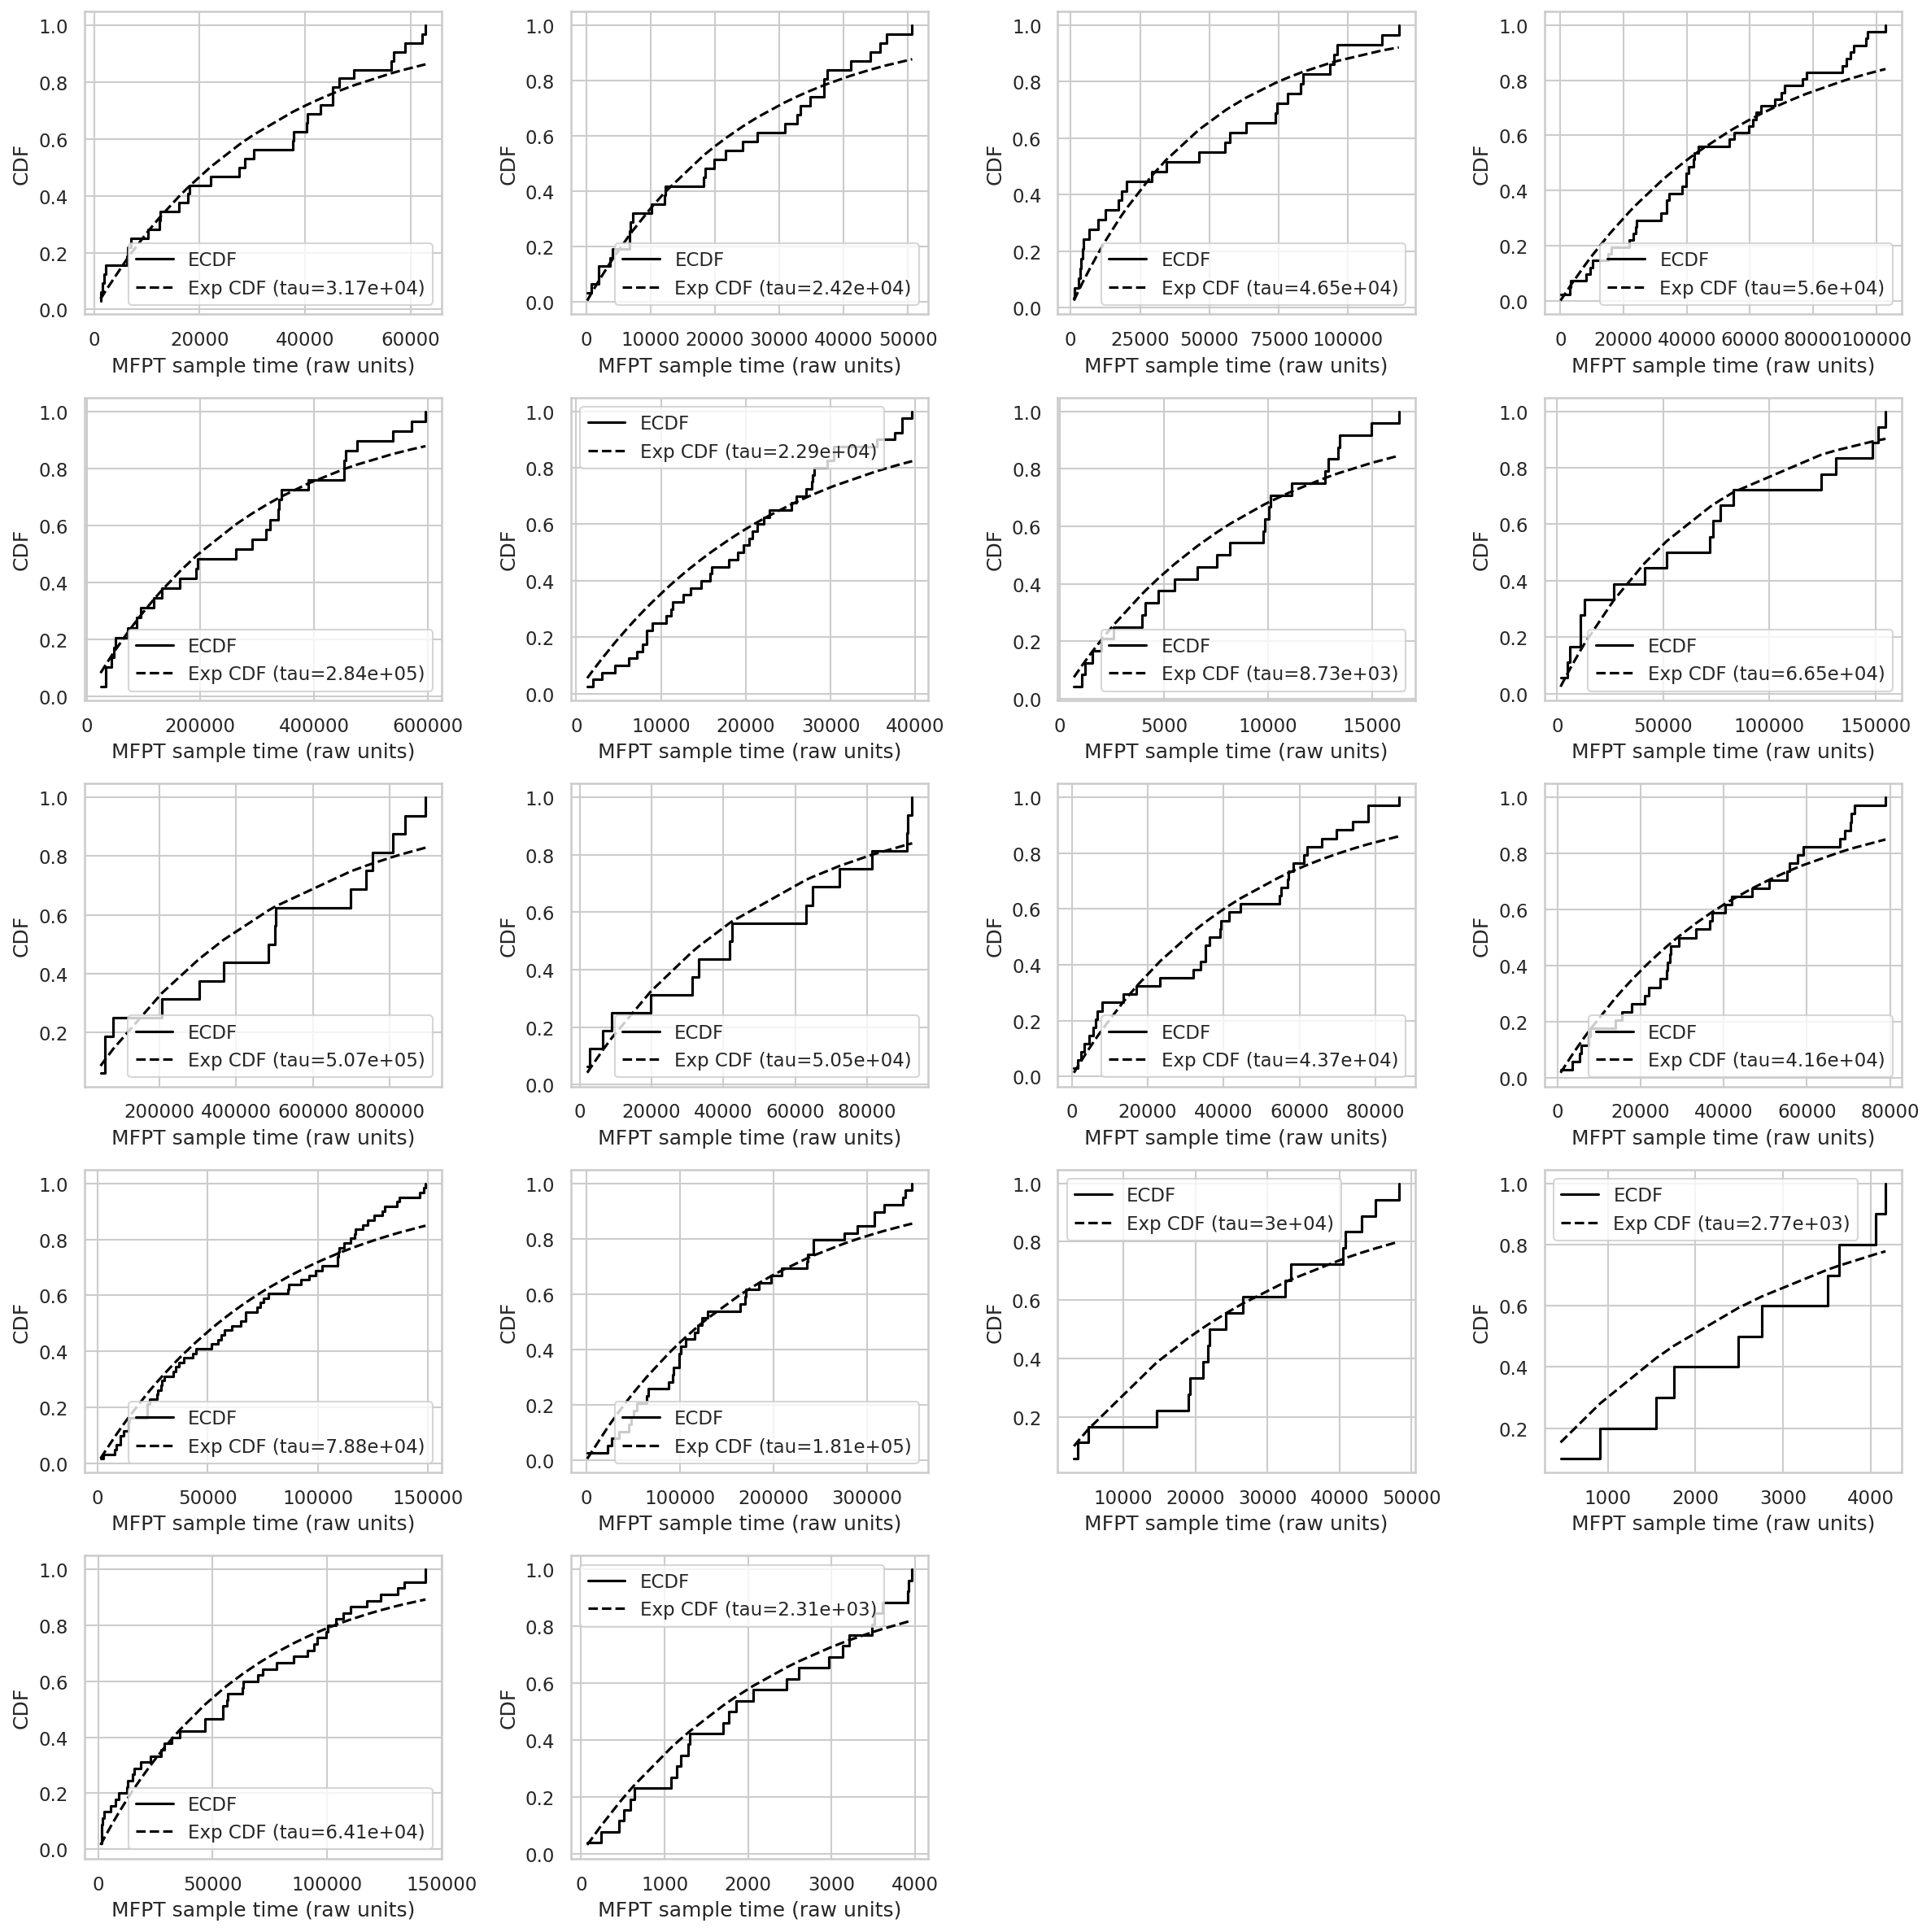

WT | KS p=0.33, Lillie p=0.14 (WT only)


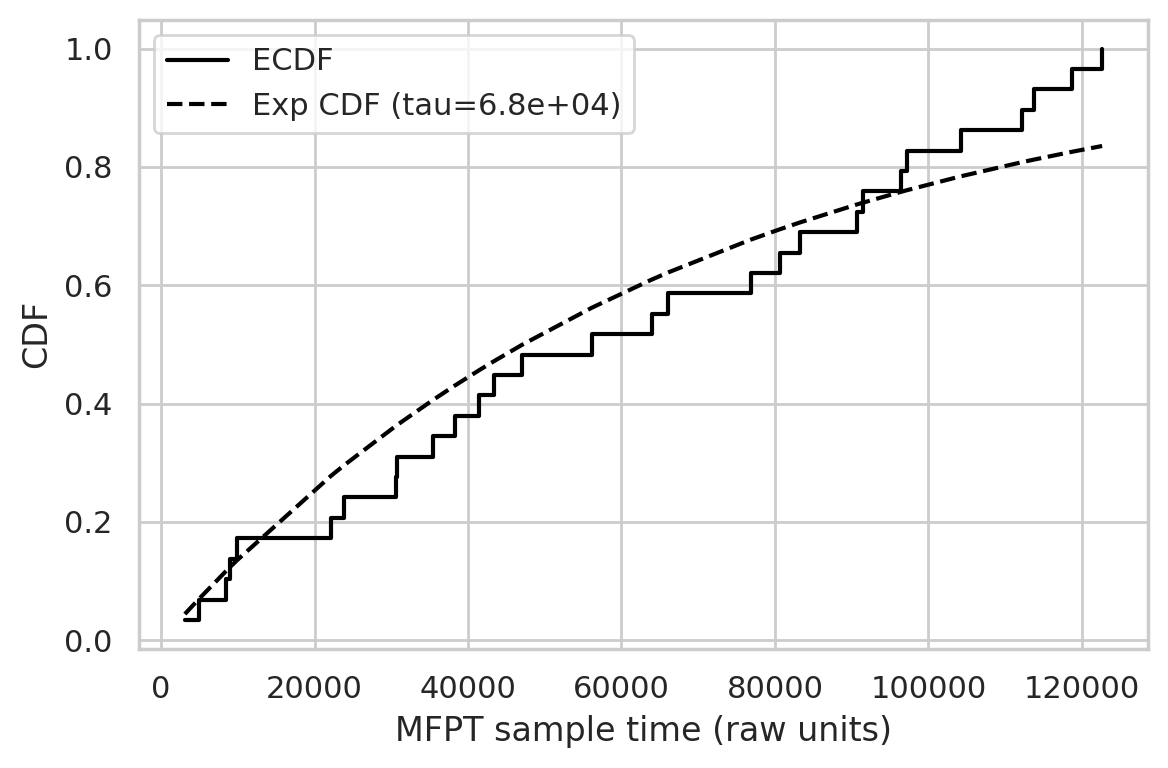

In [9]:
# ECDF grid for the best-by-median-KS-p threshold
# ECDF grid for the best-by-median-KS-p threshold
th_ecdf = float(best_by_ks_p['threshold'])

ncols = 4
m = len(names)
nrows = int(np.ceil(m / ncols))

# split rows across two figures
rows_split = int(np.ceil(nrows / 2))

# --- Figure 1 ---
fig1, axes1 = plt.subplots(rows_split, ncols, figsize=(4 * ncols, 3.2 * rows_split), squeeze=False, dpi=150)

for i, name in enumerate(names):
    r, c = divmod(i, ncols)
    if r >= rows_split:
        continue
    samples = np.array(all_mfpt[name][th_ecdf], float)
    samples = samples[np.isfinite(samples)]
    samples.sort()
    _, k_dyn = estimateMFPT(samples, k)
    s = samples[:k_dyn]

    x = s
    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau):
        return 1 - np.exp(-t / tau)
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)
    ks_D, ks_p = stats.kstest(x, 'expon', args=(0, tau))
    lillie_D, lillie_p = lilliefors(x, dist='exp')

    ax = axes1[r, c]
    ax.step(x, ecdf, where='post', label='ECDF', color='black')
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})", color='black', linestyle='--')
    ax.set_xlabel('MFPT sample time (raw units)')
    ax.set_ylabel('CDF')
    ax.legend()

for ax in axes1.ravel()[min(m, rows_split * ncols):]:
    ax.axis('off')

fig1.tight_layout()
plt.show()

# --- Figure 2 ---
rows2 = nrows - rows_split
fig2, axes2 = plt.subplots(rows2, ncols, figsize=(4 * ncols, 3.2 * rows2), squeeze=False, dpi=150)

for i, name in enumerate(names):
    r, c = divmod(i, ncols)
    if r < rows_split:
        continue
    r2 = r - rows_split
    samples = np.array(all_mfpt[name][th_ecdf], float)
    samples = samples[np.isfinite(samples)]
    samples.sort()
    _, k_dyn = estimateMFPT(samples, k)
    s = samples[:k_dyn]

    x = s
    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau):
        return 1 - np.exp(-t / tau)
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)
    ks_D, ks_p = stats.kstest(x, 'expon', args=(0, tau))
    lillie_D, lillie_p = lilliefors(x, dist='exp')

    ax = axes2[r2, c]
    ax.step(x, ecdf, where='post', label='ECDF', color='black')
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})", color='black', linestyle='--')
    ax.set_xlabel('MFPT sample time (raw units)')
    ax.set_ylabel('CDF')
    ax.legend()

for ax in axes2.ravel()[max(0, m - rows_split * ncols):]:
    ax.axis('off')

fig2.tight_layout()
plt.show()
# --- WT only (separate figure, no title) ---
name = 'WT'
print(f"{name} | KS p={ks_p:.2g}, Lillie p={lillie_p:.2g} (WT only)")
samples = np.array(all_mfpt[name][th_ecdf], float)
samples = samples[np.isfinite(samples)]
samples.sort()
_, k_dyn = estimateMFPT(samples, k)
s = samples[:k_dyn]

x = s
n = x.size
ecdf = np.arange(1, n + 1) / n

def F(t, tau):
    return 1 - np.exp(-t / tau)

tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
th = stats.expon.cdf(x, scale=tau)
ks_D, ks_p = stats.kstest(x, 'expon', args=(0, tau))
lillie_D, lillie_p = lilliefors(x, dist='exp')

fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=200)
ax.step(x, ecdf, where='post', label='ECDF', color='black')
ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})", color='black', linestyle='--')
ax.set_xlabel('MFPT sample time (raw units)')
ax.set_ylabel('CDF')
ax.legend()
fig.tight_layout()
plt.show()
